# ZXZ Y tensor network factorization sweep

Created: 15-06-2026

Objectives:
* Build off [previous notebook](quspin_zxz_y_rdm_tensor_network_factorization.ipynb), sweep procedure over many parameters.
* Investigate accuracy close to critical point.

# Imports

In [1]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
from tqdm import tqdm

In [4]:
from functools import reduce

In [5]:
import quimb.tensor as qtn
import quimb as qu

# Definitions
## Groundstates

In [6]:
num_sites = 16

In [7]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [8]:
# Use periodic boundary conditions.
def get_hamiltoniain(t, L=num_sites):
    static = [
        ["zxz", [[-t, i, (i+1)%L, (i+2)%L] for i in range(L)]],
        ["y", [[-(1-t), i] for i in range(L)]],
    ]
    dynamic = []

    basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)
    out = hamiltonian(
        static,
        [],
        basis=basis,
        dtype=np.complex128,
        check_symm=False,
        check_herm=False
    )

    return out

In [9]:
parameters = np.linspace(0, 1, 11)

In [10]:
hamiltonians = [
    get_hamiltoniain(t, num_sites)
    for t in parameters
]

In [11]:
energies = list()
groundstates = list()

for h in tqdm(hamiltonians):
    e, psi = h.eigsh(k=1, which='SA')

    energies.append(e)
    groundstates.append(psi)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:06<00:00,  1.76it/s]


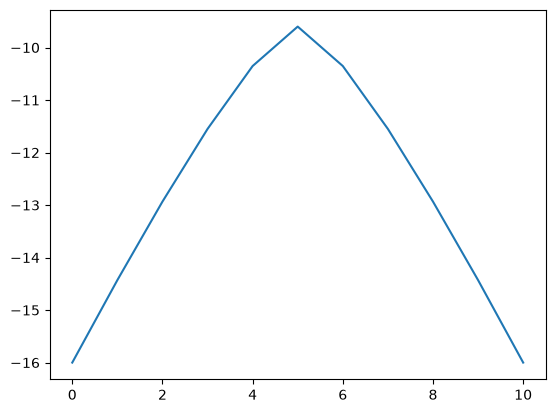

In [12]:
plt.plot(energies)

## Symmetries
Symmetry of the system is $XK$, where $K$ is complex conjugation.

In [13]:
np_X = np.array([
    [0,1],
    [1,0]
])

np_XX = np.kron(np_X, np_X)

In [14]:
qu_XX = qtn.Tensor(
    np_XX,
    inds=['k', 'b']
)

## Defect operators

In [15]:
symmetry_sites = list(range(4, 12))

num_symmetry_sites = len(symmetry_sites)

In [16]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [17]:
horiztonal_bond_dimension = 16
vertical_bond_dimension = 4

In [18]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [19]:
def get_rho_A(A):
    A_bottom = A.conj().reindex({'kl': 'bl', 'kr': 'br'})
    return A & A_bottom

In [20]:
def rho_A_trace(rho_A):
    out = (
        rho_A
        .reindex({'bl': 'kl', 'br': 'kr'})
        .contract()
    )
    return out

In [21]:
def normalize_A(A):
    rho_A = get_rho_A(A)
    trace = rho_A_trace(rho_A)
    return A.multiply(trace**(-0.5))

In [22]:
transpose_reindex_dict = {
    'bl': 'kl',
    'br': 'kr',
    'kl': 'bl',
    'kr': 'br'
}

In [23]:
def rho_A_purity(rho_A):
    tn = (
        (rho_A.reindex(transpose_reindex_dict))
        & rho_A
    )

    out = tn.contract()

    return out

In [24]:
def rho_A_rho_overlap(rho, rho_A):
    tn = (
        (rho_A.reindex(transpose_reindex_dict))
        & rho
    )

    out = tn.contract()

    return out

In [25]:
def loss_func(A, rho, rho_purity):
    rho_A = get_rho_A(A)

    out = np.real(
        rho_purity
        + rho_A_purity(rho_A)
        -2*rho_A_rho_overlap(rho, rho_A)
    )

    return out

In [26]:
def get_tensor_network_factorization(psi):
    rho = basis.partial_trace(
        psi,
        sub_sys_A=symmetry_sites,
        return_rdm="A",
        enforce_pure=True
    )

    rho_purity = np.real(np.trace(rho @ rho))

    # Hardcode warning
    rho_reshaped = rho.reshape((16, 16, 16, 16,))
    
    qt_rho = qtn.Tensor(
        data=rho_reshaped,
        inds=('kl', 'kr', 'bl', 'br')
    )

    A_left = qtn.Tensor(
        data=random_uniform_complex(
            (vertical_bond_dimension, 2**4, horiztonal_bond_dimension)
        ),
        inds=('vLV', 'kl', 'vH')
    )
    
    A_right = qtn.Tensor(
        data=random_uniform_complex(
            (horiztonal_bond_dimension, 2**4, vertical_bond_dimension)
        ),
        inds=('vH', 'kr', 'vRV')
    )

    A = qtn.TensorNetwork([A_left, A_right])

    tnopt = qtn.TNOptimizer(
        A,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="L-BFGS-B",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize_basinhopping(n=100,  nhop=5)

    return A_opt, tnopt.losses, tnopt.loss_best

In [27]:
def schmidt_decompose_tensor_factorization(A_opt):
    # Left side
    A_l_opt = A_opt.tensors[0]

    tn_l = (
        A_l_opt
        &
        A_l_opt.conj().reindex({'kl': 'bl', 'vH': 'vBH'})
    )
    tn_l = tn_l.contract()

    left_rho_decomp = qtn.tensor_core.tensor_split(
        tn_l,
        left_inds=['kl', 'vH'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vLV'
    )

    diff_l = (
        left_rho_decomp.contract(output_inds=tn_l.inds)
        - tn_l
    )

    left_diff = (diff_l & diff_l.conj()).contract()

    # Right side
    A_r_opt = A_opt.tensors[1]

    tn_r = (
        A_r_opt
        &
        A_r_opt.conj().reindex({'kr': 'br', 'vH': 'vBH'})
    )
    tn_r = tn_r.contract()

    right_rho_decomp = qtn.tensor_core.tensor_split(
        tn_r,
        left_inds=['kr', 'vH'],
        method='svd',
        #cutoff=1e-3,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vRV'
    )

    diff_r = (
        right_rho_decomp.contract(output_inds=tn_r.inds)
        - tn_r
    )

    right_diff = (diff_r & diff_r.conj()).contract()

    out = (
        left_rho_decomp,
        right_rho_decomp,
        left_diff,
        right_diff
    )

    return out

In [163]:
def get_defect_operators(edm, num_iters=20):
    # Assuming edm has indices [kl1, kr2, bl1, br2] each with size 4 (s sites)
    scores = list()

    left_defect_op = qtn.tensor_builder.rand_tensor(
        (4, 4),
        inds=['kl1', 'bl1'],
        dtype='complex64'
    )

    right_defect_op = qtn.tensor_builder.rand_tensor(
        (4, 4),
        inds=['kr2', 'br2'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (
            (
                edm
                & left_defect_op.reindex({'kl1': 'bl1', 'bl1':'kl1'})
            )
            .contract()
        )
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        right_defect_op = qtn.Tensor(sol, inds = ['kr2', 'br2'])
        
        left_edm = (
            (
                edm
                & right_defect_op.reindex({'kr2': 'br2', 'br2':'kr2'})
            )
            .contract()    
        )
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        left_defect_op = qtn.Tensor(sol, inds = ['kl1', 'bl1'])

    return (left_defect_op, right_defect_op), scores

In [176]:
def get_defect_ops_and_indices_from_density_matrix(qt_rho):
    rho_purification = qtn.tensor_core.tensor_split(
        qt_rho,
        left_inds=['kl', 'kr'],
        method='eigh',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    purification_diff = rho_purification.contract(output_inds=qt_rho.inds) - qt_rho
    purification_diff_score = (purification_diff & purification_diff.conj()).contract()

    bra_conjugate_rho = (
        rho_purification.tensors[0]
        & rho_purification.tensors[1]
        & (rho_purification.tensors[2].conj())
    )

    (
        bra_conjugate_rho
        .tensors[0]
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'kr': ['kr1', 'kr2']},
            shape_map={'kl': (4, 4), 'kr': (4, 4)}
        )
    )
    
    (
        bra_conjugate_rho
        .tensors[2]
        .unfuse_(
            unfuse_map={'bl': ['bl1', 'bl2'], 'br': ['br1', 'br2']},
            shape_map={'bl': (4, 4), 'br': (4, 4)}
        )
    )

    # Effective density matrix
    edm = (
        bra_conjugate_rho.reindex(
            {'bl1': 'bbl1', 'bl2': 'bl2', 'br1': 'br1', 'br2': 'bbr2'}
        )
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
    )

    # Ordering of indices important here.
    edm = edm.contract(output_inds=['kl1', 'kr2', 'bl1', 'br2'])

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_defect_l = (
        qt_rho
        .reindex({'kr': 'br'})
        .contract()
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'bl': ['bl1', 'bl2']},
            shape_map={'kl': (4, 4), 'bl': (4,4)}
        )
        .reindex({'kl2': 'bl2'})
        .contract()
    )

    left_defect_op_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_defect_r = (
        qt_rho
        .reindex({'kl': 'bl'})
        .contract()
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2'], 'br': ['br1', 'br2']},
            shape_map={'kr': (4, 4), 'br': (4,4)}
        )
        .reindex({'kr1': 'br1'})
        .contract()
    )

    right_defect_op_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps,
        purification_diff_score
    )

    return out

In [110]:
def get_defect_ops_and_indices_from_factorized_density_matrix(qt_rho,
    left_rho_decomp, right_rho_decomp):

    bra_conjugate_left_rho_decomp = (
        left_rho_decomp.tensors[0]
        & left_rho_decomp.tensors[1]
        & (left_rho_decomp.tensors[2].conj())
    )
    
    bra_conjugate_right_rho_decomp = (
        right_rho_decomp.tensors[0]
        & right_rho_decomp.tensors[1]
        & (right_rho_decomp.tensors[2].conj())
    )

    (
        bra_conjugate_left_rho_decomp
        .tensors[0]
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2']},
            shape_map={'kl': (4, 4)}
        )
    )
    
    (
        bra_conjugate_left_rho_decomp
        .tensors[2]
        .unfuse_(
            unfuse_map={'bl': ['bl1', 'bl2']},
            shape_map={'bl': (4, 4)}
        )
    )
    
    (
        bra_conjugate_right_rho_decomp
        .tensors[0]
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2']},
            shape_map={'kr': (4, 4)}
        )
    )
    
    (
        bra_conjugate_right_rho_decomp
        .tensors[2]
        .unfuse_(
            unfuse_map={'br': ['br1', 'br2']},
            shape_map={'br': (4, 4)}
        )
    )

    # Effective density matrix
    edm = (
        bra_conjugate_left_rho_decomp.reindex({'bl1': 'bbl1', 'bl2': 'bl2'})
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
        & bra_conjugate_right_rho_decomp.reindex({'br1': 'br1', 'br2': 'bbr2'})
    )

    edm = edm.contract(output_inds=['kl1', 'kr2', 'bl1', 'br2'])

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    left_edm = split_edm.tensors[0].isel({'vH': 0})

    u, s, vh = qtn.tensor_core.tensor_split(
        left_edm,
        left_inds=['kl1'],
        absorb=None,
        bond_ind='v'
    )

    left_defect_operator = (
        (u & vh)
        .contract()
        .conj()
        .reindex({'kl1': 'bl1', 'bl1': 'kl1'})
    )

    left_score = np.sum(s.data)

    right_edm = split_edm.tensors[2].isel({'vH': 0})

    u, s, vh = qtn.tensor_core.tensor_split(
        right_edm,
        left_inds=['kr2'],
        absorb=None,
        bond_ind='v'
    )

    right_defect_operator = (
        (u & vh)
        .contract()
        .conj()
        .reindex({'kr2': 'br2', 'br2': 'kr2'})
    )

    right_score = np.sum(s.data)

    rho_defect_l = (
        qt_rho
        .reindex({'kr': 'br'})
        .contract()
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'bl': ['bl1', 'bl2']},
            shape_map={'kl': (4, 4), 'bl': (4,4)}
        )
        .reindex({'kl2': 'bl2'})
        .contract()
    )

    left_defect_op_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_defect_r = (
        qt_rho
        .reindex({'kl': 'bl'})
        .contract()
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2'], 'br': ['br1', 'br2']},
            shape_map={'kr': (4, 4), 'br': (4,4)}
        )
        .reindex({'kr1': 'br1'})
        .contract()
    )

    right_defect_op_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl1': 'bl1', 'bl1': 'kl1'})
        & right_defect_operator.reindex({'kr2': 'br2', 'br2': 'kr2'})
    )

    overlap = np.abs(overlap.contract())

    out = (
        left_right_singular_vals,
        left_score,
        left_defect_op_invariant,
        right_score,
        right_defect_op_invariant,
        overlap
    )

    return out

In [114]:
def get_defect_ops_and_indices_from_restricted_state(psi_restricted):
    psi_0 = psi_restricted

    # Effective density matrix
    edm = (
        psi_0
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
        & psi_0.reindex({
            'kl1': 'bbl1', 'kl2': 'bl2', 'kr1': 'br1', 'kr2': 'bbr2'
        })
    )

    edm = edm.contract()

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    left_edm = split_edm.tensors[0].isel({'vH': 0})

    u, s, vh = qtn.tensor_core.tensor_split(
        left_edm,
        left_inds=['kl1'],
        absorb=None,
        bond_ind='v'
    )

    left_defect_operator = (
        (u & vh)
        .contract()
        .conj()
        .reindex({'kl1': 'bl1', 'bl1': 'kl1'})
    )

    left_score = np.sum(s.data)

    right_edm = split_edm.tensors[2].isel({'vH': 0})

    u, s, vh = qtn.tensor_core.tensor_split(
        right_edm,
        left_inds=['kr2'],
        absorb=None,
        bond_ind='v'
    )

    right_defect_operator = (
        (u & vh)
        .contract()
        .conj()
        .reindex({'kr2': 'br2', 'br2': 'kr2'})
    )

    right_score = np.sum(s.data)

    rho_0 = (
        psi_0
        & psi_0.conj().reindex({'kl1': 'bl1', 'kr2': 'br2'})
    )
    
    rho_0_l = rho_0.reindex({'br2': 'kr2'}).contract()

    left_defect_op_invariant = (
        rho_0_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_0_r = rho_0.reindex({'bl1': 'kl1'}).contract()

    right_defect_op_invariant = (
        rho_0_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl1': 'bl1', 'bl1': 'kl1'})
        & right_defect_operator.reindex({'kr2': 'br2', 'br2': 'kr2'})
    )

    overlap = np.abs(overlap.contract())
    
    out = (
        left_right_singular_vals,
        left_score,
        left_defect_op_invariant,
        right_score,
        right_defect_op_invariant,
        overlap
    )

    return out

In [114]:
def get_defect_ops_and_indices_from_restricted_state(psi_restricted):
    psi_0 = psi_restricted

    # Effective density matrix
    edm = (
        psi_0
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
        & psi_0.reindex({
            'kl1': 'bbl1', 'kl2': 'bl2', 'kr1': 'br1', 'kr2': 'bbr2'
        })
    )

    edm = edm.contract()

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    left_edm = split_edm.tensors[0].isel({'vH': 0})

    u, s, vh = qtn.tensor_core.tensor_split(
        left_edm,
        left_inds=['kl1'],
        absorb=None,
        bond_ind='v'
    )

    left_defect_operator = (
        (u & vh)
        .contract()
        .conj()
        .reindex({'kl1': 'bl1', 'bl1': 'kl1'})
    )

    left_score = np.sum(s.data)

    right_edm = split_edm.tensors[2].isel({'vH': 0})

    u, s, vh = qtn.tensor_core.tensor_split(
        right_edm,
        left_inds=['kr2'],
        absorb=None,
        bond_ind='v'
    )

    right_defect_operator = (
        (u & vh)
        .contract()
        .conj()
        .reindex({'kr2': 'br2', 'br2': 'kr2'})
    )

    right_score = np.sum(s.data)

    rho_0 = (
        psi_0
        & psi_0.conj().reindex({'kl1': 'bl1', 'kr2': 'br2'})
    )
    
    rho_0_l = rho_0.reindex({'br2': 'kr2'}).contract()

    left_defect_op_invariant = (
        rho_0_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_0_r = rho_0.reindex({'bl1': 'kl1'}).contract()

    right_defect_op_invariant = (
        rho_0_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl1': 'bl1', 'bl1': 'kl1'})
        & right_defect_operator.reindex({'kr2': 'br2', 'br2': 'kr2'})
    )

    overlap = np.abs(overlap.contract())
    
    out = (
        left_right_singular_vals,
        left_score,
        left_defect_op_invariant,
        right_score,
        right_defect_op_invariant,
        overlap
    )

    return out

In [175]:
def get_defect_ops_and_indices_from_restricted_purification_state(psi_restricted):
    psi_0 = psi_restricted

    # Effective density matrix
    edm = (
        psi_0
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
        & psi_0.reindex({
            'kl1': 'bbl1', 'kl2': 'bl2', 'kr1': 'br1', 'kr2': 'bbr2'
        })
    )

    edm = edm.contract()

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_0 = (
        psi_0
        & psi_0.conj().reindex({'kl1': 'bl1', 'kr2': 'br2'})
    )
    
    rho_0_l = rho_0.reindex({'br2': 'kr2'}).contract()

    left_defect_op_invariant = (
        rho_0_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_0_r = rho_0.reindex({'bl1': 'kl1'}).contract()

    right_defect_op_invariant = (
        rho_0_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    
    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps
    )

    return out

In [72]:
def get_restricted_psis(left_rho_decomp, right_rho_decomp, cutoff_factor=0.8):
    out = list()

    left_schmidt_vals = left_rho_decomp.tensors[1].data
    right_schmidt_vals = right_rho_decomp.tensors[1].data

    
    
    for i, sl in enumerate(left_schmidt_vals):
        if sl >= cutoff_factor*max(left_schmidt_vals):
            left_psi = left_rho_decomp.tensors[0].isel({'vLV': i})
            for j, sr in enumerate(right_schmidt_vals):
                if sr >= cutoff_factor*max(right_schmidt_vals):
                    right_psi = right_rho_decomp.tensors[0].isel({'vRV': j})

                    psi = left_psi & right_psi
                    psi_norm = (psi & psi.conj()).contract()

                    (
                        psi
                        .multiply(
                            psi_norm**(-0.5),
                            inplace=True,
                            spread_over=2
                        )
                    )

                    (
                        psi
                        .tensors[0]
                        .unfuse_(
                            unfuse_map={'kl': ['kl1', 'kl2']},
                            shape_map={'kl': (4, 4)}
                        )
                    )

                    (
                        psi
                        .tensors[1]
                        .unfuse_(
                            unfuse_map={'kr': ['kr1', 'kr2']},
                            shape_map={'kr': (4, 4)}
                        )
                    )

                    out.append([psi, sl, sr])

    return out

In [184]:
def get_restricted_psis_from_purification(qt_rho, cutoff_factor=0.65):
    out = list()

    rho_purification = qtn.tensor_core.tensor_split(
        qt_rho,
        left_inds=['kl', 'kr'],
        method='eigh',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    purification_diff = rho_purification.contract(output_inds=qt_rho.inds) - qt_rho
    purification_diff_score = (purification_diff & purification_diff.conj()).contract()

    schmidt_vals = rho_purification.tensors[1].data
    
    for i, schmidt_val in enumerate(schmidt_vals):
        if schmidt_val >= cutoff_factor*max(schmidt_vals):
            psi = rho_purification.tensors[0].isel({'vV': i})
            psi_norm = (psi & psi.conj()).contract()

            psi = psi_norm**(-0.5)*psi

            (
                psi
                .unfuse_(
                    unfuse_map={'kl': ['kl1', 'kl2'], 'kr': ['kr1', 'kr2']},
                    shape_map={'kl': (4, 4), 'kr': (4, 4)}
                )
            )

            out.append([psi, schmidt_val])

    return (out, purification_diff_score)

In [188]:
def extract_time_reversal_information(psi):
    rho = basis.partial_trace(
        psi,
        sub_sys_A=symmetry_sites,
        return_rdm="A",
        enforce_pure=True
    )
    
    rho_purity = np.real(np.trace(rho @ rho))
    
    # Hardcode warning
    rho_reshaped = rho.reshape((16, 16, 16, 16,))
    
    qt_rho = qtn.Tensor(
        data=rho_reshaped,
        inds=('kl', 'kr', 'bl', 'br')
    )

    rho_out = get_defect_ops_and_indices_from_density_matrix(qt_rho)

    pair = get_restricted_psis_from_purification(qt_rho)
    purification_restricted_psi_triples, purification_diff_scores = pair

    purification_restricted_psi_output = list()
    for psi_0, sv in purification_restricted_psi_triples:
        purification_restricted_psi_output.append(
            [sv, *get_defect_ops_and_indices_from_restricted_purification_state(psi_0)]
        )
    
    A_opt, A_losses, A_opt_best_loss = get_tensor_network_factorization(psi)

    schmidt_decomp_out = schmidt_decompose_tensor_factorization(A_opt)
    
    (
        left_rho_decomp,
        right_rho_decomp,
        left_diff,
        right_diff
    ) = schmidt_decomp_out

    rho_defect_out = get_defect_ops_and_indices_from_factorized_density_matrix(
        qt_rho,
        left_rho_decomp,
        right_rho_decomp,
    )

    (
        left_right_singular_vals,
        left_score,
        left_defect_op_invariant,
        right_score,
        right_defect_op_invariant,
        rho_defect_ops_overlap
    ) = rho_defect_out

    restricted_psi_triples = get_restricted_psis(
        left_rho_decomp,
        right_rho_decomp
    )

    restricted_psi_output = list()
    for psi_0, sl, sr in restricted_psi_triples:
        restricted_psi_output.append(
            [sl, sr, *get_defect_ops_and_indices_from_restricted_state(psi_0)]
        )

    out = (
        rho_out,
        purification_restricted_psi_output,
        A_losses,
        A_opt_best_loss,
        left_diff,
        right_diff,
        left_right_singular_vals,
        left_score,
        left_defect_op_invariant,
        right_score,
        right_defect_op_invariant,
        rho_defect_ops_overlap,
        restricted_psi_output
    )

    return out

# Testing

In [171]:
psi = groundstates[0]

In [189]:
test_out = extract_time_reversal_information(psi)

In [190]:
test_rho_out = test_out[0]

In [192]:
test_rho_out

(array([1.]),
 np.complex128(1.0000000000000004+0j),
 np.complex128(1+0j),
 [np.float64(0.7976649896480431),
  np.float64(1.0000000000000004),
  np.float64(1.0000000000000002),
  np.float64(1.0000000000000002),
  np.float64(1.0000000000000002),
  np.float64(1.0000000000000004),
  np.float64(1.0000000000000002),
  np.float64(1.0),
  np.float64(1.0000000000000007),
  np.float64(1.0000000000000002),
  np.float64(1.0000000000000007),
  np.float64(1.0000000000000002),
  np.float64(1.0000000000000002),
  np.float64(1.0),
  np.float64(1.0000000000000004),
  np.float64(1.0000000000000004),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0000000000000002),
  np.float64(1.0000000000000004),
  np.float64(1.0),
  np.float64(1.0000000000000007),
  np.float64(1.0000000000000004),
  np.float64(1.0000000000000002),
  np.float64(1.0000000000000004),
  np.float64(1.0000000000000004),
  np.float64(1.0000000000000002),
  np.float64(1.0000000000000007),
  np.float64(1.00000000000000

In [193]:
test_purification_restricted_psi_output = test_out[1]

In [194]:
test_purification_restricted_psi_output

[[np.float64(1.0),
  array([1.]),
  np.complex128(1-5.551115123125783e-17j),
  np.complex128(0.9999999999999998+5.551115123125783e-17j),
  [np.float64(1.8786419563809305),
   np.float64(1.0000000000000002),
   np.float64(1.0000000000000002),
   np.float64(0.9999999999999999),
   np.float64(1.0000000000000004),
   np.float64(0.9999999999999998),
   np.float64(0.9999999999999997),
   np.float64(0.9999999999999998),
   np.float64(0.9999999999999998),
   np.float64(1.0),
   np.float64(0.9999999999999997),
   np.float64(0.9999999999999996),
   np.float64(0.9999999999999998),
   np.float64(0.9999999999999999),
   np.float64(0.9999999999999998),
   np.float64(1.0),
   np.float64(0.9999999999999999),
   np.float64(1.0),
   np.float64(0.9999999999999998),
   np.float64(1.0000000000000002),
   np.float64(1.0),
   np.float64(0.9999999999999997),
   np.float64(0.9999999999999999),
   np.float64(0.9999999999999998),
   np.float64(0.9999999999999999),
   np.float64(1.0),
   np.float64(1.0),
   np.fl

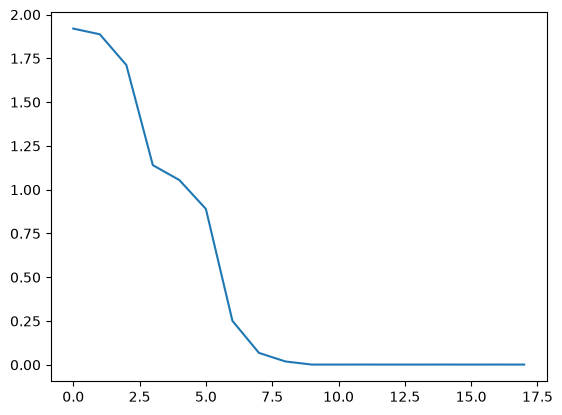

In [195]:
plt.plot(test_out[2])

In [196]:
test_out[3]

inf

In [197]:
test_out[4], test_out[5]

(np.complex64(1.3836125e-12+0j), np.complex64(1.4084681e-12+0j))

In [198]:
test_out[6]

array([9.70046508e-01, 1.37401180e-04, 1.36570306e-04, 3.90357976e-05,
       3.81813551e-05, 8.37338613e-06, 5.17364836e-06, 4.51620641e-06,
       2.49316573e-06, 1.39797465e-06, 6.89140813e-07, 5.76466216e-07,
       3.64975121e-07, 1.90350011e-07, 1.18812158e-07, 6.28154596e-08])

In [199]:
test_out[7], test_out[8]

(np.float64(1.0063439502704572),
 np.complex128(0.9999999999999962+5.043681583494219e-10j))

In [200]:
test_out[9], test_out[10]

(np.float64(1.0073337055976086),
 np.complex128(0.9999999999999977-5.658640223060729e-12j))

In [201]:
test_out[11]

np.float64(0.9833656775490225)

In [202]:
restricted_results = test_out[12]

In [203]:
restricted_results

[[np.float32(0.9968169),
  np.float32(0.98288614),
  array([9.99969594e-01, 1.34478769e-04, 1.33821982e-04, 3.65141412e-05,
         3.61038482e-05, 1.50705495e-06, 1.50646499e-06, 3.10491899e-07,
         6.40629106e-08, 2.60653527e-08, 2.03888645e-08, 1.30729458e-08,
         8.85619430e-09, 5.46912304e-09, 2.90978907e-09, 2.04546432e-09]),
  np.float64(1.0000121673179807),
  np.complex128(1.0000000447034834+6.938893903907228e-17j),
  np.float64(1.0000115726535013),
  np.complex128(1.0000000447034831-1.7971615862144574e-09j),
  np.float64(0.9999935199183217)]]

# Sweep

In [204]:
sweep_results = list()

for psi in tqdm(groundstates):
    sweep_results.append(extract_time_reversal_information(psi))

  0%|                                                                                                            | 0/11 [00:00<?, ?it/s]/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from complex64 to complex128.
  warnings.warn(
100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:12<00:00,  1.17s/it]


## Analyse results

In [207]:
rho_sweep_indices = np.array([l[0][1:3] for l in sweep_results])

In [209]:
np.round(rho_sweep_indices, 3)

array([[ 1.   +0.j   ,  1.   -0.j   ],
       [ 1.   -0.j   ,  1.   +0.j   ],
       [ 1.   +0.j   ,  1.   +0.j   ],
       [ 1.   +0.j   ,  1.   -0.j   ],
       [ 1.   +0.j   ,  1.   -0.j   ],
       [ 0.505+0.011j,  0.505+0.011j],
       [-1.   +0.j   , -1.   +0.j   ],
       [-1.   -0.j   , -1.   -0.j   ],
       [-1.   -0.j   , -1.   +0.j   ],
       [-1.   +0.j   , -1.   +0.j   ],
       [-1.   -0.j   , -1.   -0.j   ]])

In [215]:
sweep_results[0][0][0]

array([1.])

In [214]:
sweep_results[-1][0][0]

array([0.24892257, 0.02192438, 0.00665244, 0.00355258])

In [216]:
rho_purification_diff_scores = np.array([l[0][-1] for l in sweep_results])

In [217]:
rho_purification_diff_scores

array([1.23191050e-30+0.j, 7.35483755e-21+0.j, 5.44945467e-21+0.j,
       2.36587066e-20+0.j, 3.94709706e-20+0.j, 3.40667543e-20+0.j,
       2.27404992e-20+0.j, 1.74279600e-20+0.j, 1.04355290e-20+0.j,
       6.53576205e-24+0.j, 4.38223455e-31+0.j])

In [218]:
rho_overlaps = np.array([l[0][3][-1] for l in sweep_results])

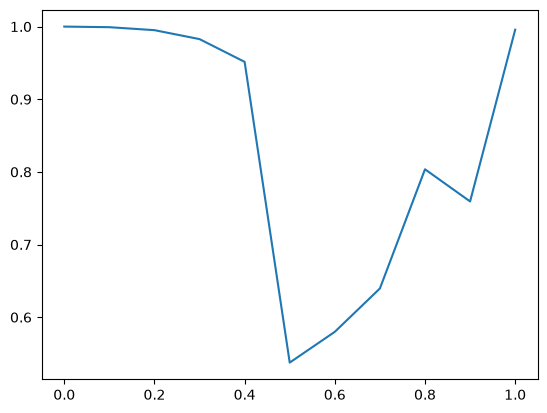

In [219]:
plt.plot(parameters, rho_overlaps)

In [220]:
sweep_results[0][1]

[[np.float64(1.0),
  array([1.]),
  np.complex128(1.0000000000000004+1.3877787807814457e-17j),
  np.complex128(1+5.551115123125783e-17j),
  [np.float64(1.652559637451774),
   np.float64(1.0000000000000002),
   np.float64(1.0),
   np.float64(0.9999999999999997),
   np.float64(1.0),
   np.float64(1.0000000000000002),
   np.float64(0.9999999999999999),
   np.float64(1.0),
   np.float64(0.9999999999999998),
   np.float64(1.0000000000000002),
   np.float64(1.0000000000000002),
   np.float64(1.0),
   np.float64(1.0),
   np.float64(0.9999999999999998),
   np.float64(0.9999999999999999),
   np.float64(1.0),
   np.float64(0.9999999999999999),
   np.float64(1.0),
   np.float64(0.9999999999999998),
   np.float64(0.9999999999999998),
   np.float64(0.9999999999999999),
   np.float64(1.0),
   np.float64(0.9999999999999998),
   np.float64(1.0),
   np.float64(0.9999999999999998),
   np.float64(0.9999999999999999),
   np.float64(1.0),
   np.float64(0.9999999999999999),
   np.float64(1.0),
   np.float64

In [221]:
sweep_results[-1][1]

[[np.float64(0.2500000000000009),
  array([4.99640378e-01, 1.34045407e-02, 1.34045407e-02, 3.59622078e-04]),
  np.complex128(-0.9999999999999998+0j),
  np.complex128(-1.0000000000000009+0j),
  [np.float64(1.2277253770042584),
   np.float64(0.9993929064967859),
   np.float64(0.9999982530702224),
   np.float64(0.9999999949777252),
   np.float64(0.9999999999855615),
   np.float64(0.9999999999999593),
   np.float64(1.0000000000000002),
   np.float64(1.0000000000000004),
   np.float64(1.0000000000000002),
   np.float64(0.9999999999999997),
   np.float64(0.9999999999999998),
   np.float64(1.0),
   np.float64(1.0000000000000002),
   np.float64(1.0),
   np.float64(1.0),
   np.float64(1.0000000000000004),
   np.float64(1.0000000000000002),
   np.float64(1.0000000000000007),
   np.float64(0.9999999999999996),
   np.float64(1.0),
   np.float64(1.0000000000000004),
   np.float64(1.0000000000000007),
   np.float64(0.9999999999999997),
   np.float64(1.0000000000000002),
   np.float64(0.9999999999999

In [222]:
sweep_results[-2][1]

[[np.float64(0.25000023135391575),
  array([2.50691926e-01, 2.49998057e-01, 2.49832005e-01, 2.49476845e-01,
         6.91367796e-04, 6.89779716e-04, 6.88525274e-04, 6.85977782e-04,
         3.51275008e-05, 3.48922963e-05, 3.48240624e-05, 3.48203463e-05,
         3.47809820e-05, 3.47779283e-05, 3.47443268e-05, 3.46497932e-05]),
  np.complex128(-0.8031608885042467+2.399055121227178e-10j),
  np.complex128(-0.8037686251854568-2.394210038558775e-10j),
  [np.float64(1.4697797033482936),
   np.float64(0.9982540659962112),
   np.float64(0.9984210968903053),
   np.float64(0.9984220159658422),
   np.float64(0.9984229355094509),
   np.float64(0.9984238557155585),
   np.float64(0.9984247765847133),
   np.float64(0.9984256981174624),
   np.float64(0.9984266203143516),
   np.float64(0.9984275431759275),
   np.float64(0.9984284667027368),
   np.float64(0.9984293908953215),
   np.float64(0.998430315754228),
   np.float64(0.9984312412799989),
   np.float64(0.9984321674731758),
   np.float64(0.998433094

Not working in this case.

In [ ]:
rho_le

In [128]:
factorization_curves = [l[0] for l in sweep_results]

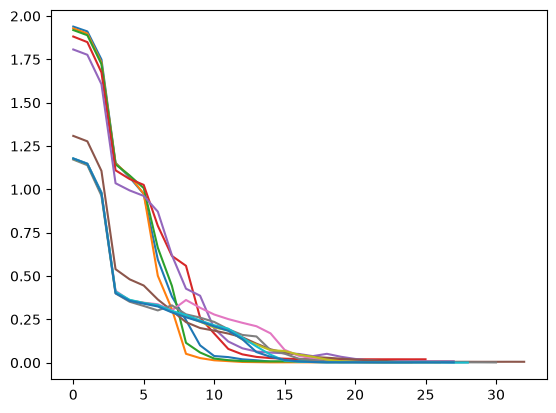

In [129]:
for l in factorization_curves:
    plt.plot(l);

In [130]:
best_factorization_loss = [min(l[0]) for l in sweep_results]

In [131]:
best_factorization_loss

[0.006211400032043457,
 0.001712203025817871,
 0.00732111930847168,
 0.019481778144836426,
 0.008046269416809082,
 0.005018293857574463,
 0.0018671154975891113,
 0.0014903843402862549,
 0.0023440122604370117,
 0.0005853772163391113,
 0.0017920434474945068]

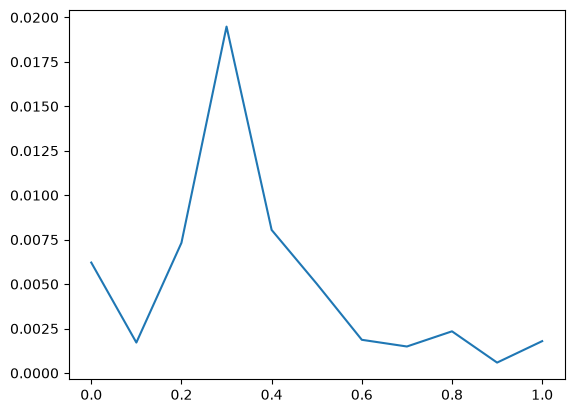

In [132]:
plt.plot(parameters, best_factorization_loss)

In [133]:
diffs = np.array([[l[2], l[3]] for l in sweep_results])

In [134]:
np.max(np.abs(diffs))

np.float32(9.387515e-12)

In [135]:
left_rho_index = np.array([l[6] for l in sweep_results])

In [136]:
np.max(np.abs(np.imag(left_rho_index)))

np.float64(1.4886240795597416e-08)

In [137]:
left_rho_index = np.real(left_rho_index)

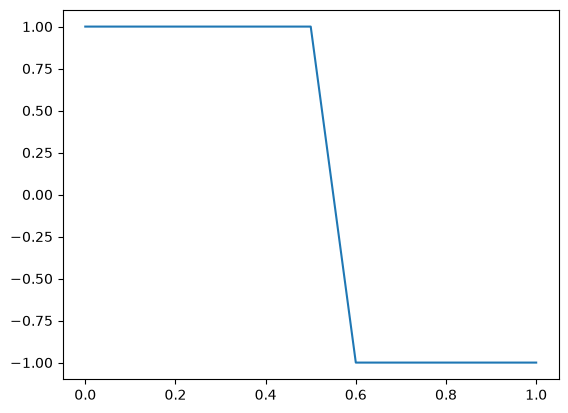

In [138]:
plt.plot(parameters, left_rho_index)

In [139]:
right_rho_index = np.array([l[8] for l in sweep_results])

In [140]:
np.max(np.abs(np.imag(right_rho_index)))

np.float64(4.813396188574348e-09)

In [141]:
right_rho_index = np.real(right_rho_index)

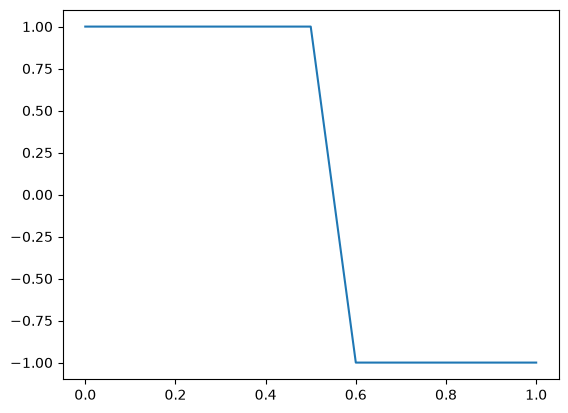

In [142]:
plt.plot(parameters, right_rho_index)

In [143]:
rho_overlaps = np.array([l[9] for l in sweep_results])

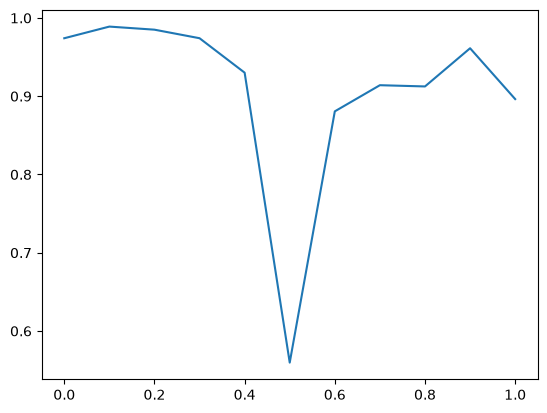

In [144]:
plt.plot(parameters, rho_overlaps)

Interesting...

In [147]:
left_state_index = np.array([np.array(np.mean([l1[4] for l1 in l[10]])) for l in sweep_results])

In [148]:
np.max(np.abs(np.imag(left_state_index)))

np.float64(9.020562075079397e-17)

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


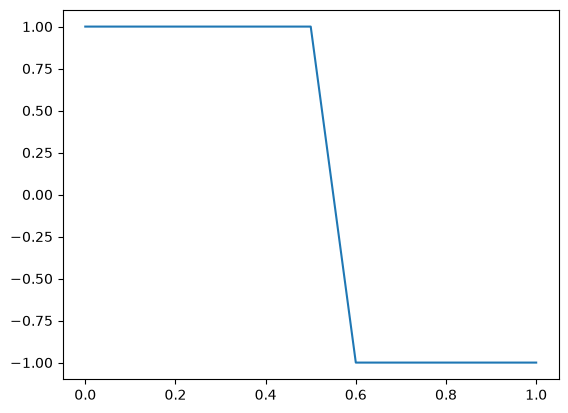

In [149]:
plt.plot(parameters, left_state_index)

In [150]:
right_state_index = np.array([np.array(np.mean([l1[6] for l1 in l[10]])) for l in sweep_results])

In [151]:
np.max(np.abs(np.imag(right_state_index)))

np.float64(1.769512887606073e-08)

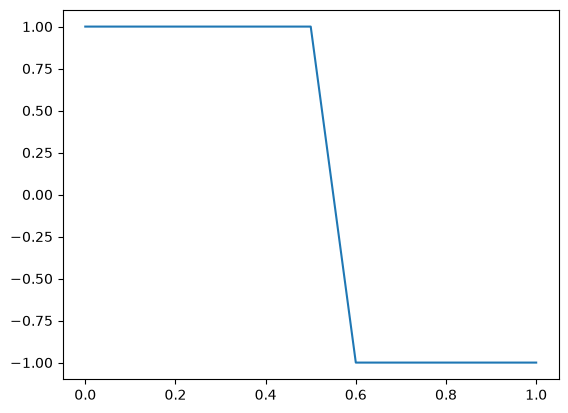

In [152]:
plt.plot(parameters, right_state_index)

In [155]:
num_restricted_states = np.array([len(l[10]) for l in sweep_results])

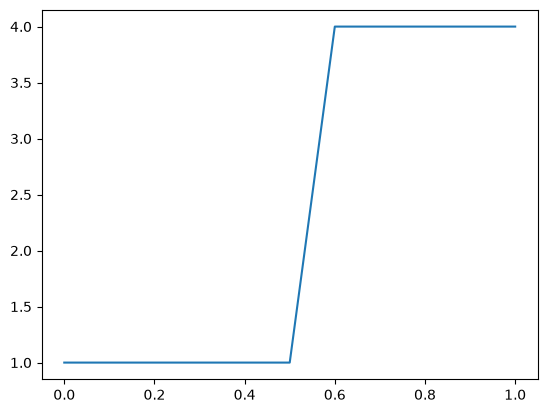

In [156]:
plt.plot(parameters, num_restricted_states)

In [159]:
state_overlaps = np.array([np.array(np.mean([l1[7] for l1 in l[10]])) for l in sweep_results])

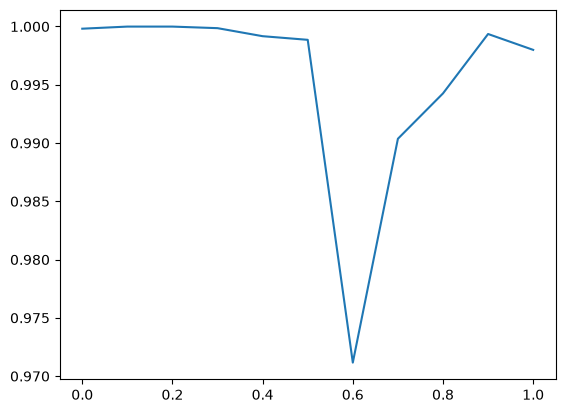

In [160]:
plt.plot(parameters, state_overlaps)